In [20]:
import sys
sys.path.append('..')
import torch
from torchvision import transforms
from PIL import Image
import glob
import base64
import matplotlib.pyplot as plt
import io

from tools.gradcam_tool import explain_gradcam

print("imports done")

imports done


In [21]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

images = glob.glob("../data/HAM10000_images_part_1/*.jpg")
test_image = transform(Image.open(images[0]).convert("RGB")).unsqueeze(0)
print("image loaded:", images[0])

image loaded: ../data/HAM10000_images_part_1\ISIC_0024306.jpg


In [50]:
result = explain_gradcam(test_image, pred_class=0)
print("status:          ", result['status'])
print("attention region:", result['attention_region'])
print("interpretation:  ", result['interpretation'])

status:           success
attention region: top-center region of the image
interpretation:   The model's attention was broadly distributed across much of the image with high gradient signal strength. High-attention coverage: 48.7% of image area.


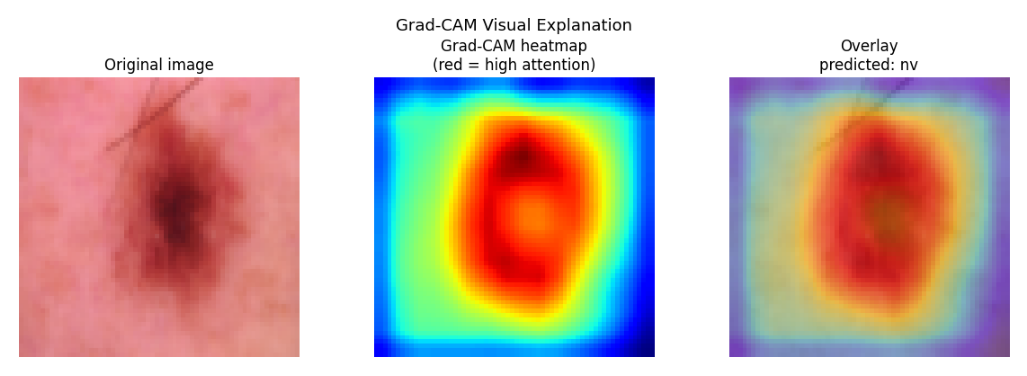

In [48]:
# display the overlay plot
img_data = base64.b64decode(result['plot_b64'])
img = Image.open(io.BytesIO(img_data))
plt.figure(figsize=(13, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [45]:
import importlib
import tools.gradcam_tool as gc_module
importlib.reload(gc_module)
from tools.gradcam_tool import explain_gradcam

result = explain_gradcam(test_image, pred_class=0)

print("status:", result['status'])
print("error:", result.get('error', 'none'))
print("plot length:", len(result['plot_b64']))

status: success
error: none
plot length: 63580


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

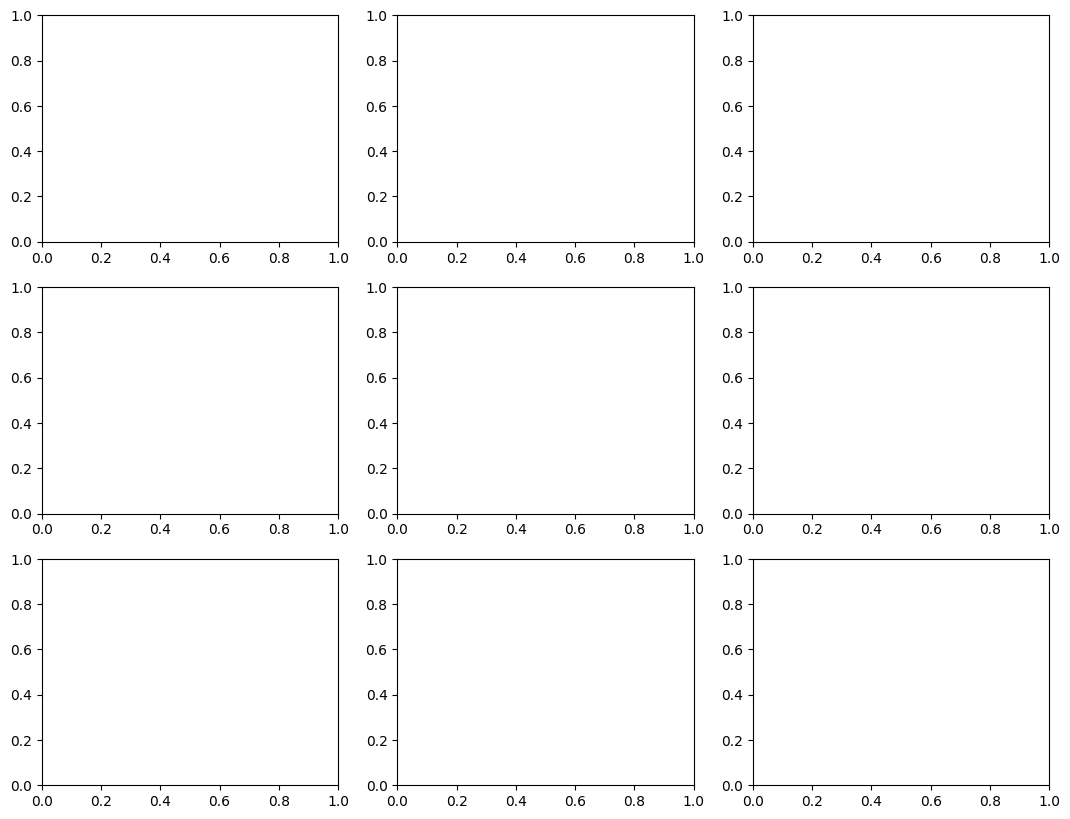

In [49]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))

for row, img_path in enumerate(images[1:4]):
    img_tensor = transform(Image.open(img_path).convert("RGB")).unsqueeze(0)
    res = explain_gradcam(img_tensor, pred_class=0)

    orig = img_tensor[0].permute(1, 2, 0).numpy()
    orig = (orig * 0.5 + 0.5).clip(0, 1)

    import numpy as np
    import matplotlib.cm as cm
    cam = np.array(res['heatmap'])
    heatmap = cm.jet(cam)[:, :, :3]
    overlay = (0.55 * orig + 0.45 * heatmap).clip(0, 1)

    axes[row][0].imshow(orig)
    axes[row][0].set_title("original")
    axes[row][0].axis("off")

    axes[row][1].imshow(cam, cmap='jet')
    axes[row][1].set_title("grad-cam")
    axes[row][1].axis("off")

    axes[row][2].imshow(overlay)
    axes[row][2].set_title(res['attention_region'])
    axes[row][2].axis("off")

plt.suptitle("Grad-CAM across 3 different lesion images", fontsize=13)
plt.tight_layout()
plt.show()

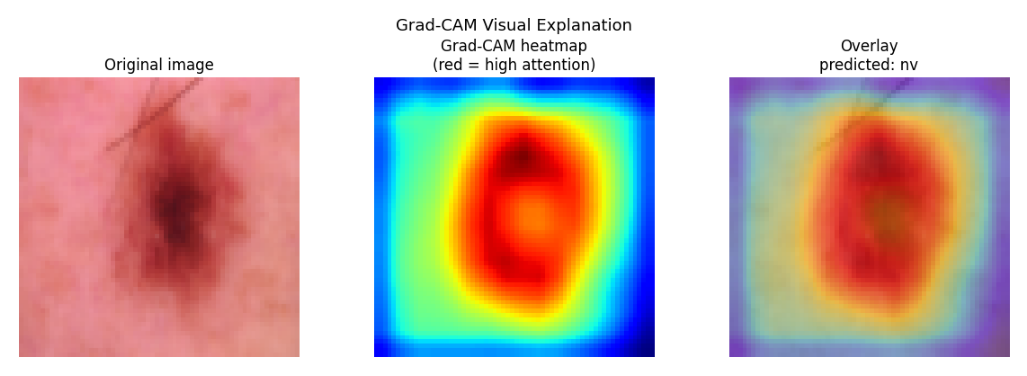

In [47]:
img_data = base64.b64decode(result['plot_b64'])
img = Image.open(io.BytesIO(img_data))
plt.figure(figsize=(13, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [5]:
print("status:", result['status'])
print("error:", result.get('error', 'no error'))
print("plot_b64 length:", len(result['plot_b64']))

status: error
error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
plot_b64 length: 0


In [19]:
print("status:", result['status'])
print("error:", result.get('error', 'none'))
print("plot_b64 length:", len(result['plot_b64']))
print("attention region:", result.get('attention_region', 'none'))

status: error
error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
plot_b64 length: 0
attention region: unknown
